# Exploración visual del dataset BreastDCEDL

Objetivo: **entender los datos antes de construir la CNN**. Este notebook es solo para
*mirar*: las comprobaciones formales están en `src/eda.py`.

Regla: todo lo que compara **pCR=0 frente a pCR=1** se hace **solo con train**. De test
solo contamos pacientes, para no mirar el conjunto de evaluación final antes de tiempo.

Funciona en **Google Colab** (descarga los datos automáticamente) o en local si el
repositorio tiene `data/breastdcedl/`.

## 0. Preparación: datos y librerías

In [30]:

import sys
from pathlib import Path
RAIZ = next((p /"data"/"breastdcedl" for p in [Path.cwd(), *Path.cwd().parents]
if (p /"data"/"breastdcedl" / "metadata" / "samples.csv").exists()), None)
assert RAIZ is not None, "No encuentro data/breastdcedl. Ejecuta el notebook dentro del repo."
sys.path.insert(0, str(RAIZ))
import utils_caso as uc # utilidades del profesor
print("Datos en:", RAIZ)


Datos en: /home/aulas/Escritorio/CLAUDIA/caso01_cancer/data/breastdcedl


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

COLOR = {0: "#2a78d6", 1: "#eb6834"}               # pCR=0 azul, pCR=1 naranja
ETQ = {0: "no pCR (0)", 1: "pCR (1)"}
FASES = ("PRE", "EARLY", "LATE")
rng = np.random.default_rng(42)                     # semilla fija: mismas figuras siempre

samples = uc.cargar_samples(RAIZ)                   # 1 fila por corte
patients = uc.cargar_patients(RAIZ)                 # 1 fila por paciente

# Tabla por paciente con la cohorte y el subtipo, que usaremos en todo el notebook
pac = (samples.groupby("patient_id")
       .agg(split=("split", "first"), pCR=("pCR", "first"), fold=("fold", "first"),
            n_cortes=("sample_id", "size"))
       .join(patients.set_index("pid")[["dataset", "HR_HER2_STATUS", "age", "tum_vol"]]))
train_pac = pac[pac.split == "train"]
print(f"{len(samples)} cortes, {len(pac)} pacientes")

12703 cortes, 1273 pacientes


## 1. Qué hay en los CSV

- `samples.csv`: **una fila por corte**, con las rutas de sus 3 PNG (PRE, EARLY, LATE),
  la etiqueta y el fold.
- `patients.csv`: **una fila por paciente**, con variables clínicas. Solo sirven para
  interpretar; la red **no** las recibe.

In [32]:
samples.head()

,sample_id,patient_id,split,path_pre,path_early,path_late,slice_index,pCR,fold
0,ISPY1_1001_z012,ISPY1_1001,train,dataset/train/ISPY1_1001/ISPY1_1001_z012_PRE.png,dataset/train/ISPY1_1001/ISPY1_1001_z012_EARLY...,dataset/train/ISPY1_1001/ISPY1_1001_z012_LATE.png,12,0,0
1,ISPY1_1001_z013,ISPY1_1001,train,dataset/train/ISPY1_1001/ISPY1_1001_z013_PRE.png,dataset/train/ISPY1_1001/ISPY1_1001_z013_EARLY...,dataset/train/ISPY1_1001/ISPY1_1001_z013_LATE.png,13,0,0
2,ISPY1_1001_z014,ISPY1_1001,train,dataset/train/ISPY1_1001/ISPY1_1001_z014_PRE.png,dataset/train/ISPY1_1001/ISPY1_1001_z014_EARLY...,dataset/train/ISPY1_1001/ISPY1_1001_z014_LATE.png,14,0,0
3,ISPY1_1001_z015,ISPY1_1001,train,dataset/train/ISPY1_1001/ISPY1_1001_z015_PRE.png,dataset/train/ISPY1_1001/ISPY1_1001_z015_EARLY...,dataset/train/ISPY1_1001/ISPY1_1001_z015_LATE.png,15,0,0
4,ISPY1_1001_z016,ISPY1_1001,train,dataset/train/ISPY1_1001/ISPY1_1001_z016_PRE.png,dataset/train/ISPY1_1001/ISPY1_1001_z016_EARLY...,dataset/train/ISPY1_1001/ISPY1_1001_z016_LATE.png,16,0,0


In [33]:
patients.head()

,pid,pCR,n_xy,n_z,n_times,pre,post_early,post_late,slice_thick,xy_spacing,mask_start,mask_end,sraw,eraw,scol,ecol,tum_vol,age,menopause,race_white,race_black,HR,HER2,HR_HER2_STATUS,TripleNeg,HER2pos,HRposHER2neg,dataset,test,split
0,ISPY1_1001,0,256.0,60.0,3.0,0.0,1.0,2.0,2.0,0.781250,12.0,38.0,110.0,192.0,59.0,144.0,21.156006,38.73,NaN,1.0,0.0,1.0,0.0,HRposHER2neg,0.0,0.0,1.0,spy1,0,train
1,ISPY1_1002,0,256.0,60.0,3.0,0.0,1.0,2.0,2.0,0.781250,10.0,28.0,121.0,163.0,101.0,144.0,5.310059,37.79,NaN,1.0,0.0,1.0,0.0,HRposHER2neg,0.0,0.0,1.0,spy1,0,train
2,ISPY1_1003,0,256.0,60.0,3.0,0.0,1.0,2.0,2.0,0.781250,14.0,36.0,136.0,199.0,29.0,113.0,13.092041,49.83,NaN,1.0,0.0,1.0,0.0,HRposHER2neg,0.0,0.0,1.0,spy1,0,train
3,ISPY1_1004,0,256.0,60.0,3.0,0.0,1.0,2.0,1.5,0.703125,8.0,49.0,25.0,198.0,81.0,181.0,42.757855,48.28,NaN,1.0,0.0,0.0,0.0,TripleNeg,1.0,0.0,0.0,spy1,1,test
4,ISPY1_1005,0,256.0,60.0,3.0,0.0,1.0,2.0,1.8,0.703125,5.0,44.0,17.0,139.0,74.0,190.0,36.433982,45.80,NaN,1.0,0.0,1.0,0.0,HRposHER2neg,0.0,0.0,1.0,spy1,0,train


## 1b. Calidad de las variables: ¿faltan datos? ¿hay que excluir algo?

Dos tipos de variables:

- **Lo que usa la red:** las 3 imágenes y la etiqueta `pCR` (`samples.csv`). Si faltara algo aquí,
  habría que excluir pacientes.
- **Variables clínicas y técnicas** (`patients.csv`): **no entran en la red**. Solo sirven para
  interpretar y estudiar sesgos, así que un valor faltante no obliga a excluir a nadie.

In [34]:
def calidad(df: pd.DataFrame) -> pd.DataFrame:
    """Tipo, % de faltantes, nº de valores distintos y rango/valores de cada columna."""
    filas = []
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s) and s.nunique() > 5:
            valores = f"{s.min():.4g} – {s.max():.4g}"
        else:
            valores = ", ".join(map(str, sorted(s.dropna().unique())[:4])) + (" …" if s.nunique() > 4 else "")
        filas.append({"columna": c, "tipo": str(s.dtype), "faltan_%": round(s.isna().mean() * 100, 1),
                      "distintos": s.nunique(), "valores": valores})
    return pd.DataFrame(filas).set_index("columna")

print("samples.csv  (lo que usa la red)")
display(calidad(samples))
print("patients.csv (solo para interpretar)")
display(calidad(patients))

samples.csv  (lo que usa la red)


,tipo,faltan_%,distintos,valores
columna,,,,
sample_id,str,0.0,12703,"ACRIN-6698-102212_z020, ACRIN-6698-102212_z021..."
patient_id,str,0.0,1273,"ACRIN-6698-102212, ACRIN-6698-103939, ACRIN-66..."
split,str,0.0,2,"test, train"
path_pre,str,0.0,12703,dataset/test/ACRIN-6698-102212/ACRIN-6698-1022...
path_early,str,0.0,12703,dataset/test/ACRIN-6698-102212/ACRIN-6698-1022...
path_late,str,0.0,12703,dataset/test/ACRIN-6698-102212/ACRIN-6698-1022...
slice_index,int64,0.0,86,0 – 85
pCR,int64,0.0,2,"0, 1"
fold,int64,0.0,6,-1 – 4


patients.csv (solo para interpretar)


,tipo,faltan_%,distintos,valores
columna,,,,
pid,str,0.0,1273,"ACRIN-6698-102212, ACRIN-6698-103939, ACRIN-66..."
pCR,int64,0.0,2,"0, 1"
n_xy,float64,0.0,7,128 – 512
n_z,float64,0.0,101,9 – 256
n_times,float64,0.0,9,3 – 11
pre,float64,0.0,1,0.0
post_early,float64,0.0,3,"1.0, 2.0, 3.0"
post_late,float64,0.0,6,2 – 7
slice_thick,float64,0.0,46,0.8 – 4


In [35]:
# Comprobaciones de lo que usa la red
excluidas = pd.read_csv(RAIZ / "metadata" / "excluded_patients.csv")
print(f"Etiquetas pCR nulas:              {samples.pCR.isna().sum()}")
print(f"Pacientes sin metadatos clínicos: {len(set(samples.patient_id) - set(patients.pid))}")
print(f"Pacientes con < 10 cortes:        {(pac.n_cortes < 10).sum()}  (se mantienen: datos válidos)")
print(f"Excluidas por los autores:        {len(excluidas)}  -> {', '.join(excluidas.patient_id)}")

Etiquetas pCR nulas:              0
Pacientes sin metadatos clínicos: 0
Pacientes con < 10 cortes:        7  (se mantienen: datos válidos)
Excluidas por los autores:        2  -> Breast_MRI_001, Breast_MRI_003


In [36]:
# ¿Dónde faltan las variables clínicas? (% de faltantes por cohorte)
clinicas = ["age", "tum_vol", "menopause", "HR", "HER2", "HR_HER2_STATUS"]
display((patients.groupby("dataset")[clinicas].apply(lambda d: d.isna().mean() * 100)).round(1))

print("Pacientes sin subtipo (quedan fuera SOLO del análisis por subtipo):")
display(patients.loc[patients.HR_HER2_STATUS.isna(), ["pid", "dataset", "split", "HR", "HER2"]])

,age,tum_vol,menopause,HR,HER2,HR_HER2_STATUS
dataset,,,,,,
duke,0.0,0.4,0.0,0.0,0.0,0.0
spy1,0.0,0.0,100.0,1.4,3.6,3.6
spy2,0.3,0.0,3.7,0.0,0.0,0.0


Pacientes sin subtipo (quedan fuera SOLO del análisis por subtipo):


,pid,dataset,split,HR,HER2
69,ISPY1_1142,spy1,test,1.0,NaN
70,ISPY1_1144,spy1,train,0.0,NaN
79,ISPY1_1159,spy1,train,NaN,NaN
87,ISPY1_1173,spy1,train,NaN,NaN
103,ISPY1_1192,spy1,test,0.0,NaN


n_times              slice_thick             xy_spacing               \
            min median   max         min median  max        min median   max   
dataset                                                                        
duke        3.0    4.0   5.0        1.04    2.0  2.5       0.53   0.70  1.25   
spy1        3.0    3.0   6.0        1.50    2.3  4.0       0.39   0.78  1.09   
spy2        4.0    7.0  11.0        0.80    2.0  3.0       0.31   0.68  1.41   

          n_xy                
           min median    max  
dataset                       
duke     256.0  256.0  448.0  
spy1     256.0  256.0  512.0  
spy2     128.0  256.0  448.0

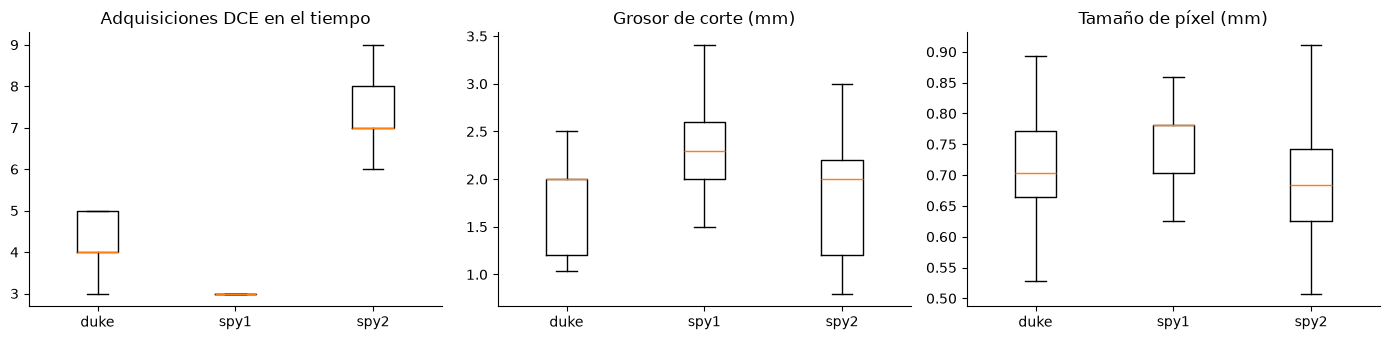

In [37]:
# Variables técnicas de adquisición por cohorte: ¿se hicieron igual las resonancias?
tecnicas = ["n_times", "slice_thick", "xy_spacing", "n_xy"]
display(patients.groupby("dataset")[tecnicas].agg(["min", "median", "max"]).round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
cohortes = sorted(patients.dataset.unique())
for ax, var, titulo in zip(axes, ["n_times", "slice_thick", "xy_spacing"],
                           ["Adquisiciones DCE en el tiempo", "Grosor de corte (mm)", "Tamaño de píxel (mm)"]):
    ax.boxplot([patients.loc[patients.dataset == c, var].dropna() for c in cohortes], showfliers=False)
    ax.set_xticks(range(1, len(cohortes) + 1), cohortes)
    ax.set_title(titulo)
plt.tight_layout(); plt.show()

**Qué concluir (compruébalo con tus salidas):**

- **No se excluye ninguna paciente adicional:** `pCR` y las 3 fases están completas en las 1.273 pacientes.
  Las 2 problemáticas ya las excluyeron los autores del dataset. Las pocas pacientes con menos de 10
  cortes se mantienen.
- **Variables clínicas:** `menopause` falta en toda la cohorte I-SPY1, así que no sirve para comparar
  cohortes. El subtipo falta en 5 pacientes de I-SPY1: quedan fuera solo de la tabla por subtipo.
  Las variables de raza no se analizan.
- **Adquisición:** los protocolos de resonancia son muy distintos entre cohortes (número de tiempos, grosor
  de corte, resolución). Aunque el dataset lo homogeneiza todo a 256×256, esas diferencias pueden dejar
  huella en la imagen: **refuerza el riesgo de sesgo por cohorte** (sección 7).

## 2. Cuántos datos hay y cómo están las clases

La unidad estadística es la **paciente**. Los ~10 cortes de una paciente son rebanadas
vecinas de la misma mama: son muy parecidos entre sí, no son 10 casos independientes.

Pacientes por split y clase:


pCR,0,1
split,,
test,123,53
train,775,322


Cortes por split y clase:


pCR,0,1
split,,
test,1228,530
train,7729,3216


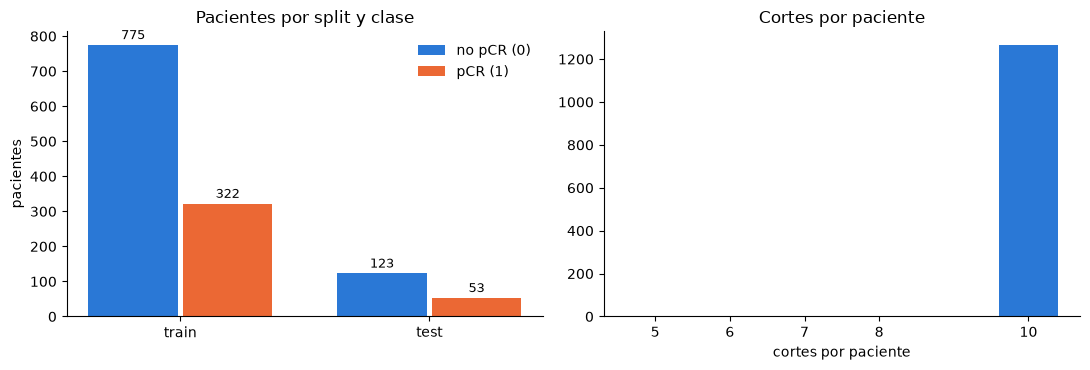

pos_weight = N0/N1 = 7729/3216 = 2.40
Predecir siempre 0 daría accuracy = 69.9% en test


In [38]:
print("Pacientes por split y clase:")
display(pac.groupby(["split", "pCR"]).size().unstack())
print("Cortes por split y clase:")
display(samples.groupby(["split", "pCR"]).size().unstack())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
t = pac.groupby(["split", "pCR"]).size().unstack().reindex(["train", "test"])
x = np.arange(2)
for k, c in enumerate((0, 1)):
    b = axes[0].bar(x + (k - .5) * .38, t[c], .36, color=COLOR[c], label=ETQ[c])
    axes[0].bar_label(b, padding=2, fontsize=9)
axes[0].set_xticks(x, t.index); axes[0].set_ylabel("pacientes")
axes[0].set_title("Pacientes por split y clase"); axes[0].legend(frameon=False)

cuentas = pac.n_cortes.value_counts().sort_index()
axes[1].bar(cuentas.index, cuentas.values, color=COLOR[0])
axes[1].set_xticks(cuentas.index); axes[1].set_xlabel("cortes por paciente")
axes[1].set_title("Cortes por paciente")
plt.tight_layout(); plt.show()

n0, n1 = (samples[samples.split == "train"].pCR.value_counts().sort_index())
print(f"pos_weight = N0/N1 = {n0}/{n1} = {n0/n1:.2f}")
print(f"Predecir siempre 0 daría accuracy = {1 - pac[pac.split=='test'].pCR.mean():.1%} en test")

## 3. Separación por paciente y folds

Ninguna paciente puede estar en dos splits ni en dos folds; si no, habría **fuga de datos**.
Los 5 folds dividen train para la validación interna.

Pacientes en más de un split: 0
Pacientes de train en más de un fold: 0


,pacientes,prop_pCR
fold,,
0,219,0.292
1,219,0.283
2,220,0.268
3,220,0.341
4,219,0.283


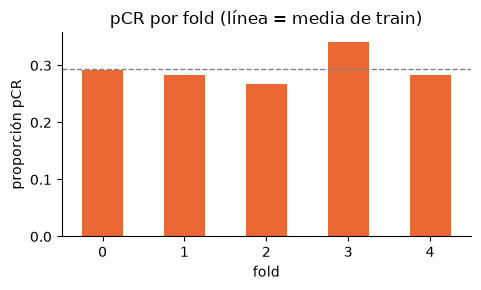

In [39]:
print("Pacientes en más de un split:", (samples.groupby("patient_id").split.nunique() > 1).sum())
print("Pacientes de train en más de un fold:",
      (samples[samples.split == "train"].groupby("patient_id").fold.nunique() > 1).sum())

folds = train_pac.groupby("fold").agg(pacientes=("pCR", "size"), prop_pCR=("pCR", "mean"))
display(folds.round(3))
ax = folds.prop_pCR.plot.bar(color=COLOR[1], figsize=(5, 3), rot=0)
ax.axhline(train_pac.pCR.mean(), color="gray", ls="--", lw=1)
ax.set_ylabel("proporción pCR"); ax.set_title("pCR por fold (línea = media de train)")
plt.tight_layout(); plt.show()

## 4. Ver un corte: las tres fases y el realce

- **PRE**: antes del contraste. **EARLY**: poco después. **LATE**: varios minutos después.
- **Realce = EARLY − PRE**: lo que se ilumina al llegar el contraste. Es la señal del problema.

Cambia `SAMPLE_ID` por cualquier corte de `samples.csv`.

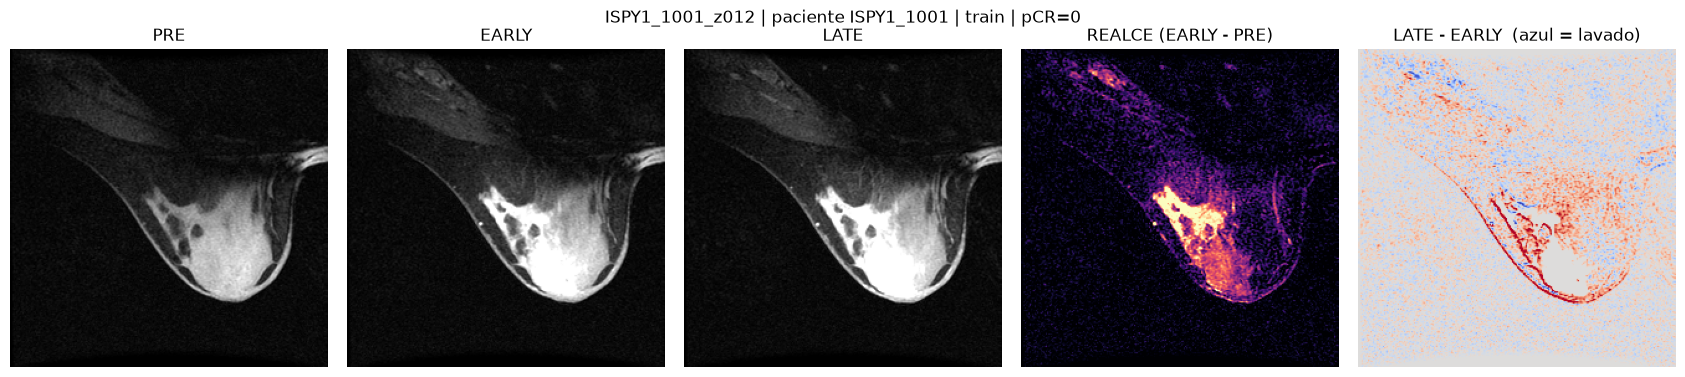

forma: (3, 256, 256) | rango: 0.0 - 1.0


In [40]:
def cargar(sample_id):
    fila = samples.loc[samples.sample_id == sample_id].iloc[0]
    return fila, uc.cargar_imagen(fila, RAIZ)       # (3, 256, 256) en [0, 1]: lo que verá la red

def ver_corte(sample_id):
    fila, x = cargar(sample_id)
    realce = x[1] - x[0]
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
    for ax, img, fase in zip(axes, x, FASES):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1); ax.set_title(fase)
    axes[3].imshow(np.clip(realce, 0, None), cmap="magma", vmin=0, vmax=0.4)
    axes[3].set_title("REALCE (EARLY - PRE)")
    axes[4].imshow(x[2] - x[1], cmap="coolwarm", vmin=-0.2, vmax=0.2)
    axes[4].set_title("LATE - EARLY  (azul = lavado)")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"{sample_id} | paciente {fila.patient_id} | {fila.split} | pCR={fila.pCR}")
    plt.tight_layout(); plt.show()
    print("forma:", x.shape, "| rango:", round(float(x.min()), 3), "-", round(float(x.max()), 3))

SAMPLE_ID = samples[samples.split == "train"].sample_id.iloc[0]
ver_corte(SAMPLE_ID)

## 5. Ver todos los cortes de una paciente

Los cortes `z` son **alturas** distintas de la mama (no instantes de tiempo).

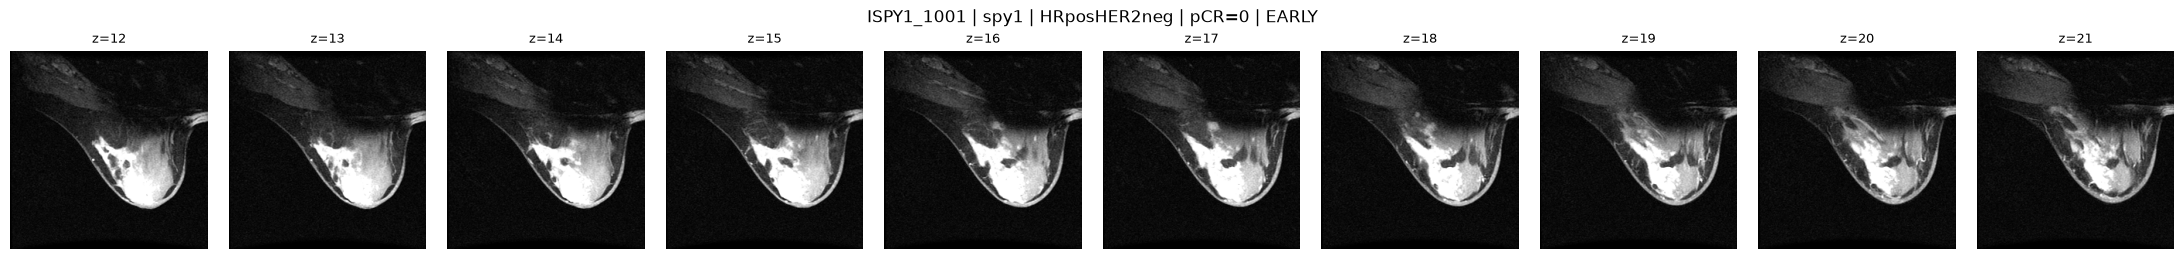

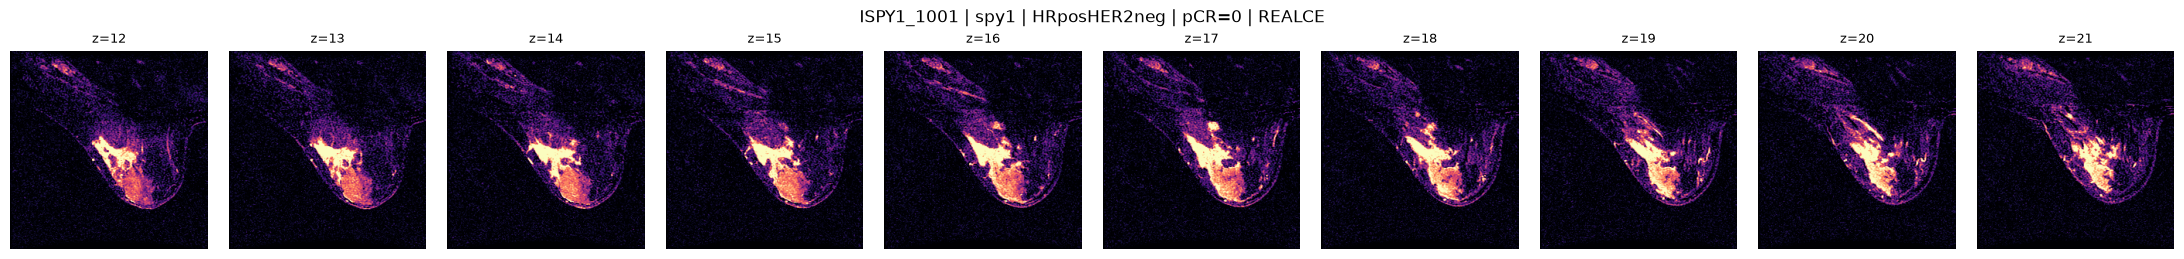

In [41]:
def ver_paciente(patient_id, modo="EARLY"):
    cortes = samples[samples.patient_id == patient_id].sort_values("slice_index")
    n = len(cortes)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))
    for ax, fila in zip(np.atleast_1d(axes), cortes.itertuples()):
        x = uc.cargar_imagen(fila, RAIZ)
        if modo == "REALCE":
            ax.imshow(np.clip(x[1] - x[0], 0, None), cmap="magma", vmin=0, vmax=0.4)
        else:
            ax.imshow(x[FASES.index(modo)], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"z={fila.slice_index}", fontsize=9); ax.axis("off")
    info = pac.loc[patient_id]
    fig.suptitle(f"{patient_id} | {info.dataset} | {info.HR_HER2_STATUS} | pCR={info.pCR} | {modo}")
    plt.tight_layout(); plt.show()

PACIENTE = samples.loc[samples.sample_id == SAMPLE_ID, "patient_id"].iloc[0]
ver_paciente(PACIENTE, "EARLY")
ver_paciente(PACIENTE, "REALCE")

## 6. pCR=0 frente a pCR=1 (train)

Corte central de 3 pacientes de cada clase, elegidas al azar. **Pregunta:** ¿ves a simple
vista algo que distinga las dos clases? Si no, es normal: el problema es difícil.

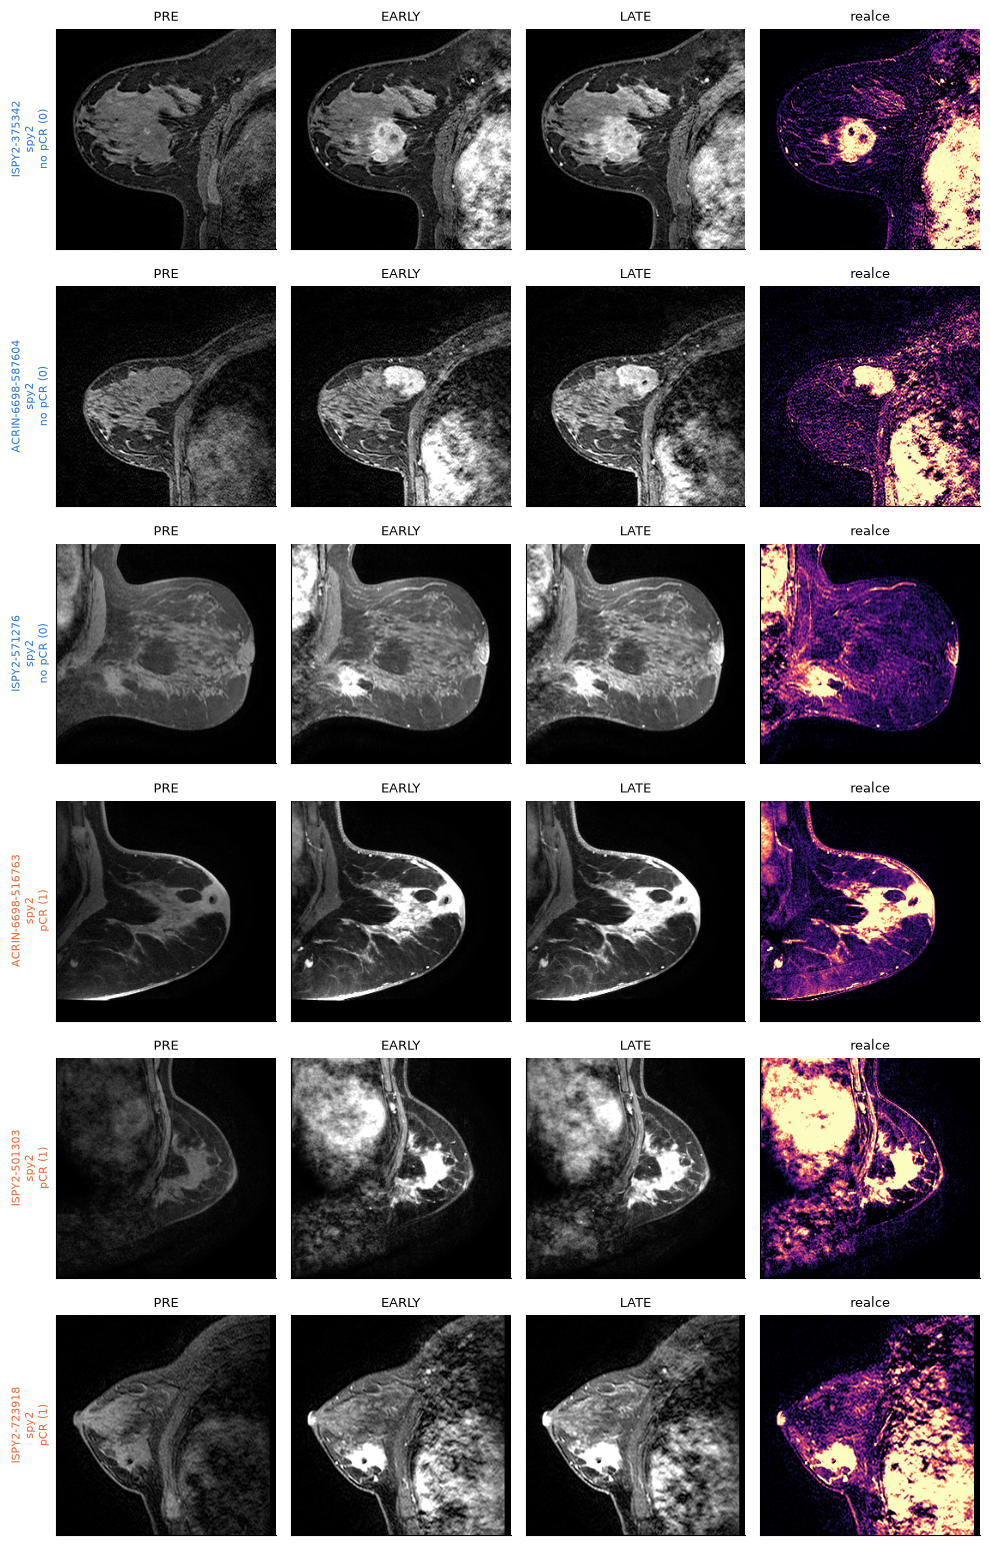

In [42]:
def comparar_clases(n=3):
    tr = train_pac
    filas = [(pid, c) for c in (0, 1)
             for pid in rng.choice(tr[tr.pCR == c].index, n, replace=False)]
    fig, axes = plt.subplots(len(filas), 4, figsize=(10, 2.6 * len(filas)))
    for fila_ax, (pid, c) in zip(axes, filas):
        cortes = samples[samples.patient_id == pid].sort_values("slice_index")
        fila = cortes.iloc[len(cortes) // 2]
        x = uc.cargar_imagen(fila, RAIZ)
        for ax, img, fase in zip(fila_ax[:3], x, FASES):
            ax.imshow(img, cmap="gray", vmin=0, vmax=1); ax.set_title(fase, fontsize=9)
        fila_ax[3].imshow(np.clip(x[1] - x[0], 0, None), cmap="magma", vmin=0, vmax=0.4)
        fila_ax[3].set_title("realce", fontsize=9)
        for ax in fila_ax: ax.set_xticks([]); ax.set_yticks([])
        fila_ax[0].set_ylabel(f"{pid}\n{pac.loc[pid, 'dataset']}\n{ETQ[c]}",
                              fontsize=8, color=COLOR[c])
    plt.tight_layout(); plt.show()

comparar_clases(3)

## 7. Cohortes: ¿se distinguen las imágenes de Duke, I-SPY1 e I-SPY2?

Si cada cohorte "se ve distinta" (escáner, protocolo, recorte) **y** tiene distinta tasa de
pCR, la red podría aprender a reconocer la cohorte en vez de la biología del tumor.

,pacientes,tasa_pCR
dataset,,
duke,209,0.211
spy1,104,0.250
spy2,784,0.321


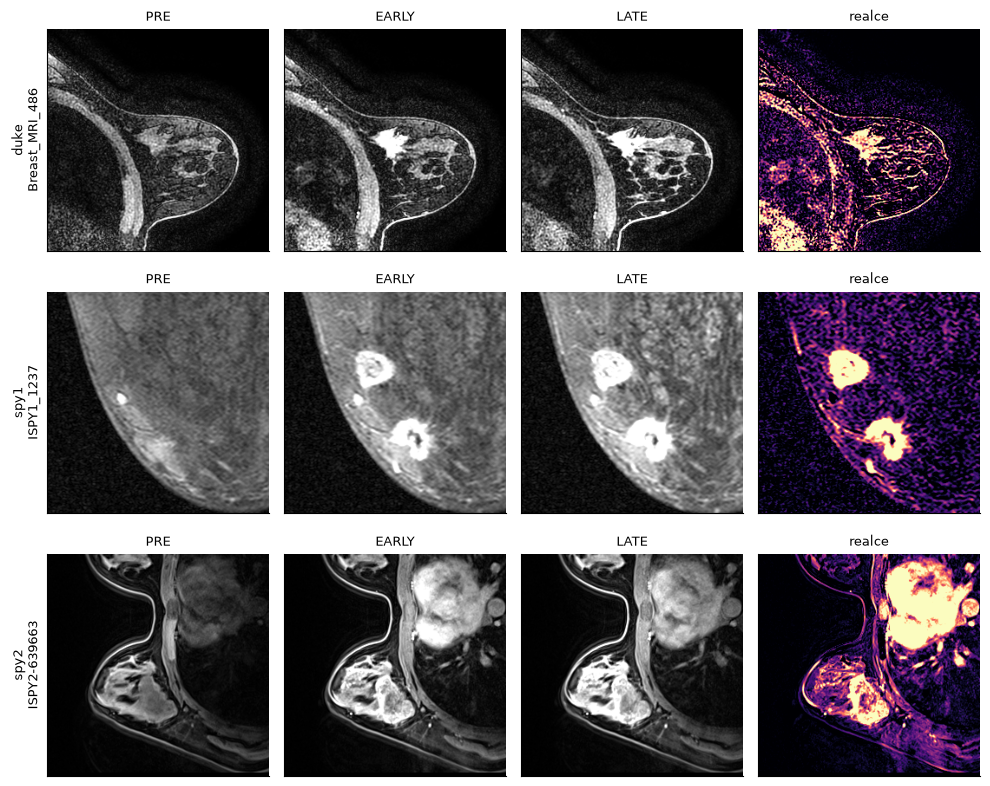

In [43]:
tasa = train_pac.groupby("dataset").pCR.agg(pacientes="size", tasa_pCR="mean")
display(tasa.round(3))

cohortes = sorted(train_pac.dataset.dropna().unique())
fig, axes = plt.subplots(len(cohortes), 4, figsize=(10, 2.7 * len(cohortes)))
for fila_ax, coh in zip(np.atleast_2d(axes), cohortes):
    pid = rng.choice(train_pac[train_pac.dataset == coh].index)
    cortes = samples[samples.patient_id == pid].sort_values("slice_index")
    x = uc.cargar_imagen(cortes.iloc[len(cortes) // 2], RAIZ)
    for ax, img, fase in zip(fila_ax[:3], x, FASES):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1); ax.set_title(fase, fontsize=9)
    fila_ax[3].imshow(np.clip(x[1] - x[0], 0, None), cmap="magma", vmin=0, vmax=0.4)
    fila_ax[3].set_title("realce", fontsize=9)
    for ax in fila_ax: ax.set_xticks([]); ax.set_yticks([])
    fila_ax[0].set_ylabel(f"{coh}\n{pid}", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Variables clínicas: subtipo tumoral, edad y volumen (train)

No entran en la red, pero ayudan a interpretar: en la literatura, los tumores **HER2+** y
**triple negativo** alcanzan pCR con más frecuencia que los **HR+/HER2−**.

% de valores faltantes:


HR_HER2_STATUS     0.4
age                0.2
tum_vol            0.1
menopause         13.5
dtype: float64

,pacientes,tasa_pCR
HR_HER2_STATUS,,
HER2pos,287,0.429
HRposHER2neg,453,0.141
TripleNeg,354,0.379


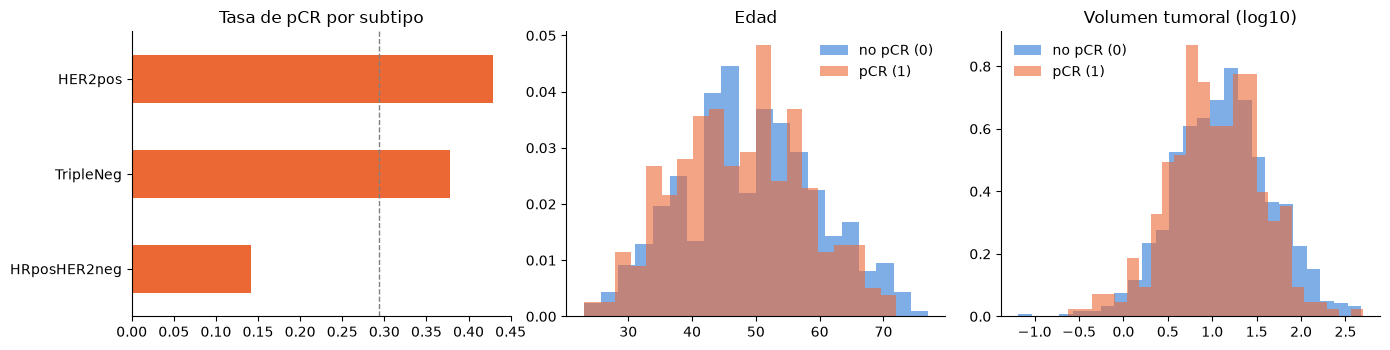

In [44]:
print("% de valores faltantes:")
display((patients[["HR_HER2_STATUS", "age", "tum_vol", "menopause"]].isna().mean() * 100).round(1))

sub = train_pac.groupby("HR_HER2_STATUS").pCR.agg(pacientes="size", tasa_pCR="mean")
display(sub.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
sub.tasa_pCR.sort_values().plot.barh(ax=axes[0], color=COLOR[1])
axes[0].axvline(train_pac.pCR.mean(), color="gray", ls="--", lw=1)
axes[0].set_title("Tasa de pCR por subtipo"); axes[0].set_ylabel("")
for c in (0, 1):
    d = train_pac[train_pac.pCR == c]
    axes[1].hist(d.age.dropna(), bins=20, alpha=.6, color=COLOR[c], label=ETQ[c], density=True)
    axes[2].hist(np.log10(d.tum_vol.dropna()), bins=25, alpha=.6, color=COLOR[c],
                 label=ETQ[c], density=True)
axes[1].set_title("Edad"); axes[1].legend(frameon=False)
axes[2].set_title("Volumen tumoral (log10)"); axes[2].legend(frameon=False)
plt.tight_layout(); plt.show()

## 9. Intensidades y curva de realce (train)

Medimos la intensidad media **en el tejido** (PRE > 0.1, para quitar el fondo negro) en cada
fase. Para que sea rápido usamos una muestra de pacientes; sube `N_POR_CLASE` si quieres más.

- Si **PRE < EARLY** en todas, las fases están bien ordenadas.
- La **curva PRE → EARLY → LATE** resume la cinética del contraste; si baja al final es **lavado**.

In [45]:
N_POR_CLASE = 150            # pacientes de train por clase (None = todas; tarda más)

def medir(fila):
    x = uc.cargar_imagen(fila, RAIZ)
    tejido = x[0] > 0.1
    return [float(c[tejido].mean()) if tejido.any() else np.nan for c in x]

elegidas = []
for c in (0, 1):
    ids = train_pac[train_pac.pCR == c].index
    elegidas += list(ids if N_POR_CLASE is None else rng.choice(ids, min(N_POR_CLASE, len(ids)), replace=False))
sub_s = samples[samples.patient_id.isin(elegidas)]
med = pd.DataFrame([medir(f) for f in sub_s.itertuples()], columns=list(FASES), index=sub_s.index)
med = sub_s[["patient_id"]].join(med).groupby("patient_id").mean().join(pac[["pCR", "dataset"]])
med["realce"] = med.EARLY - med.PRE
med["lavado"] = med.LATE < med.EARLY
print(f"{len(med)} pacientes medidas")
print(f"PRE < EARLY en el {(med.PRE < med.EARLY).mean():.1%} | lavado en el {med.lavado.mean():.1%}")
display(med.groupby("pCR")[["PRE", "EARLY", "LATE", "realce", "lavado"]].mean().round(3))

300 pacientes medidas
PRE < EARLY en el 99.7% | lavado en el 23.0%


,PRE,EARLY,LATE,realce,lavado
pCR,,,,,
0,0.276,0.413,0.432,0.138,0.22
1,0.272,0.419,0.436,0.147,0.24


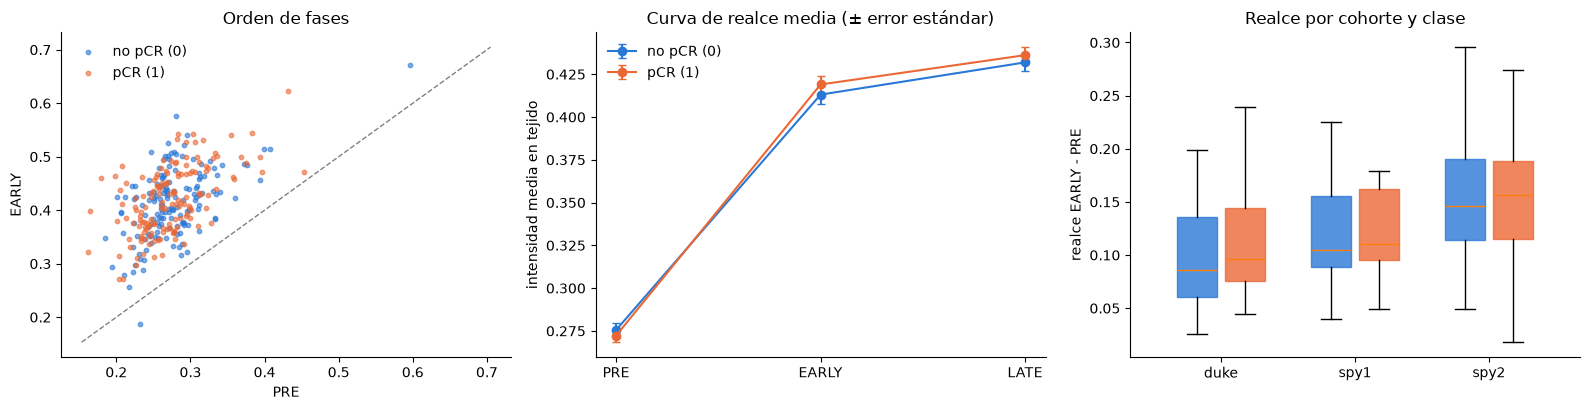

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# a) PRE frente a EARLY: todos los puntos deben quedar por encima de la diagonal
for c in (0, 1):
    d = med[med.pCR == c]
    axes[0].scatter(d.PRE, d.EARLY, s=10, alpha=.6, color=COLOR[c], label=ETQ[c])
lim = [med[["PRE", "EARLY"]].min().min() * .95, med[["PRE", "EARLY"]].max().max() * 1.05]
axes[0].plot(lim, lim, "--", color="gray", lw=1)
axes[0].set_xlabel("PRE"); axes[0].set_ylabel("EARLY")
axes[0].set_title("Orden de fases"); axes[0].legend(frameon=False)

# b) Curva media de realce por clase
for c in (0, 1):
    d = med[med.pCR == c][list(FASES)]
    m, e = d.mean(), d.std() / np.sqrt(len(d))
    axes[1].errorbar(range(3), m, yerr=e, marker="o", capsize=3, color=COLOR[c], label=ETQ[c])
axes[1].set_xticks(range(3), FASES); axes[1].set_ylabel("intensidad media en tejido")
axes[1].set_title("Curva de realce media (± error estándar)"); axes[1].legend(frameon=False)

# c) Realce por cohorte y clase
cohortes = sorted(med.dataset.dropna().unique())
for k, c in enumerate((0, 1)):
    datos = [med[(med.dataset == coh) & (med.pCR == c)].realce.dropna() for coh in cohortes]
    bp = axes[2].boxplot(datos, positions=np.arange(len(cohortes)) + (k - .5) * .36, widths=.3,
                         patch_artist=True, showfliers=False)
    for b in bp["boxes"]: b.set(facecolor=COLOR[c], edgecolor=COLOR[c], alpha=.8)
axes[2].set_xticks(range(len(cohortes)), cohortes)
axes[2].set_ylabel("realce EARLY - PRE"); axes[2].set_title("Realce por cohorte y clase")
plt.tight_layout(); plt.show()

## 10. Distribución de intensidades por cohorte

Histograma de los píxeles de tejido de EARLY. Si las cohortes tienen distribuciones muy
distintas, es una diferencia técnica (no biológica) que la red podría aprovechar.

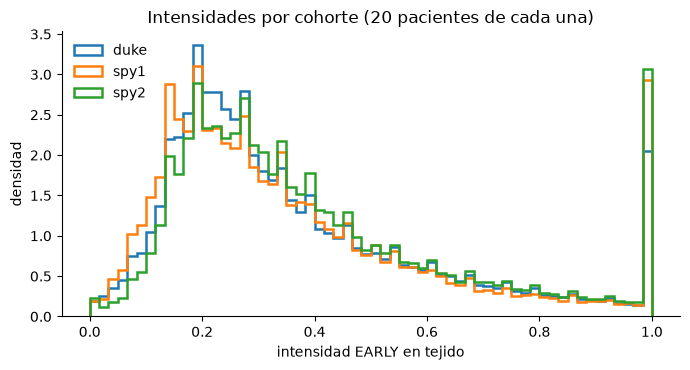

In [47]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for coh in sorted(train_pac.dataset.dropna().unique()):
    ids = rng.choice(train_pac[train_pac.dataset == coh].index, 20, replace=False)
    valores = []
    for fila in samples[samples.patient_id.isin(ids)].itertuples():
        x = uc.cargar_imagen(fila, RAIZ)
        valores.append(x[1][x[0] > 0.1])
    ax.hist(np.concatenate(valores), bins=60, histtype="step", density=True, lw=1.8, label=coh)
ax.set_xlabel("intensidad EARLY en tejido"); ax.set_ylabel("densidad")
ax.set_title("Intensidades por cohorte (20 pacientes de cada una)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 11. Conclusiones

1. **Tamaño y desbalance:** 1.273 pacientes (1.097 train, 176 test) y 12.703 cortes;
   casi todas las pacientes aportan 10 cortes (7 tienen entre 5 y 8). La unidad
   estadística es la paciente: los ~10 cortes de una misma paciente están
   correlacionados. Desbalance ≈ 70/30 (29 % pCR en train, 30 % en test), que refleja
   la tasa real de respuesta completa. Predecir siempre "no pCR" ya daría un 69,9 % de
   accuracy en test, así que la accuracy no sirve como métrica principal.

2. **Separación por paciente y folds:** ninguna paciente aparece en dos splits ni en
   dos folds, por lo que no hay fuga de datos. Los 5 folds tienen ~219 pacientes cada uno,
   pero la proporción de pCR varía entre folds (del 26,8 % en el fold 2 al 34,1 % en el
   fold 3), así que las métricas de validación pueden depender del fold elegido.

3. **¿Se distinguen pCR=0 y pCR=1?** A simple vista [sí / no se aprecian diferencias
   claras entre clases en las fases ni en el mapa de realce]. En el realce medio
   EARLY − PRE por paciente: [pCR=0 = __ ; pCR=1 = __], y el lavado aparece en el
   [__ %] de las pacientes. [Las curvas de realce de ambas clases se solapan / difieren
   en __], lo que indica que el problema es difícil y que la señal, si existe, es sutil.

4. **Diferencias entre cohortes:** la tasa de pCR varía entre cohortes (Duke 21 %,
   I-SPY1 25 %, I-SPY2 32 %), en parte porque Duke tiene más tumores HR+/HER2− (51 %).
   Los protocolos de adquisición también difieren (número de tiempos DCE, grosor de
   corte, resolución original) y [las imágenes / los histogramas de intensidad de cada
   cohorte se ven parecidos / distintos en __]. Riesgo: la red podría aprender a
   reconocer la cohorte en lugar de la biología del tumor, y "acertar" por el motivo
   equivocado. Habrá que evaluar el modelo por cohorte.

5. **Subtipo tumoral:** es el factor más asociado a la respuesta (pCR del 43 % en HER2+,
   38 % en triple negativo y 14 % en HR+/HER2−). La CNN no recibe el subtipo, pero si
   la imagen refleja rasgos del subtipo, el modelo podría estar aprendiendo "qué subtipo
   es" más que "cómo responderá". Conviene analizar los resultados por subtipo.
   No se excluye ninguna paciente: el subtipo solo falta en 5 pacientes (I-SPY1) y
   menopausia en toda la cohorte I-SPY1, pero esas variables no son entradas del modelo.

6. **Decisiones para la CNN:**
   - Separación por paciente con los folds dados; test solo al final.
   - Pérdida ponderada con pos_weight = N0/N1 ≈ 2,40 (comparada con la normal).
   - Métricas a nivel de paciente: AUC, sensibilidad, especificidad y matriz de
     confusión, además de la accuracy.
   - Preprocesado mínimo: solo /255, sin normalizar cada fase por separado (se
     destruiría el realce) ni normalización de ImageNet.
   - Aumento de datos solo geométrico (volteo horizontal, rotación y traslación
     pequeñas) aplicado igual a las 3 fases; nada fotométrico.
   - Red pequeña y regularizada (~393 K parámetros, dropout, weight decay, early
     stopping) por el tamaño reducido del conjunto.
   - Evaluar también por cohorte y por subtipo para detectar sesgos.